<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Week4_Day3_ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [5]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [7]:
import zipfile # Importation du module pour manipuler les fichiers zip
import pandas as pd # Importation de pandas pour la manipulation de données
import os # Importation d'os pour interagir avec le système de fichiers
from sklearn.model_selection import train_test_split # Pour diviser les données

# Chemin du fichier zip
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
# Dossier d'extraction
EXTRACT_DIR = 'heart_ds'

# Création du dossier d'extraction s'il n'existe pas
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR) # Crée le répertoire

# Extraction du fichier ZIP s'il existe
if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR) # Extrait tout dans le dossier spécifié

# Lister les fichiers CSV extraits (vérifie si le dossier contient des fichiers)
csv_files = [f for f in os.listdir(EXTRACT_DIR) if f.endswith('.csv')] if os.path.exists(EXTRACT_DIR) else []
# Sélectionner le premier fichier CSV trouvé
csv_path = os.path.join(EXTRACT_DIR, csv_files[0]) if csv_files else None

# Charger le CSV dans un DataFrame nommé df
df = None # Initialisation de la variable
if csv_path:
    df = pd.read_csv(csv_path) # Lecture du fichier

# Inspection rapide des premières lignes si df est chargé
if df is not None:
    display(df.head()) # Affiche les 5 premières lignes
    # Identifier la colonne cible (supposée être 'target' ou 'HeartDisease')
    target = 'target' if 'target' in df.columns else df.columns[-1] # Nom de la colonne à prédire

    # Séparation des caractéristiques (X) et de la cible (y)
    X = df.drop(columns=[target]) # On enlève la colonne cible de X
    y = df[target] # On garde uniquement la cible dans y

    # Division en train/test avec stratification sur y
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    ) # 80% train, 20% test

### Basic visual checks

In [26]:
# Visualisation des colonnes numériques (Vérification si df existe)
if 'df' in globals() and df is not None:
    df.select_dtypes(include=['number']).hist(figsize=(10, 8)) # Trace des histogrammes pour chaque variable numérique
    plt.tight_layout() # Ajuste la disposition des graphiques
    plt.show() # Affiche la figure

    # Visualisation de l'équilibre des classes
    df[target].value_counts().plot(kind='bar', color=['skyblue', 'salmon']) # Compte et trace les classes
    plt.title('Équilibre des classes (Cible)') # Ajoute un titre
    plt.xlabel('Classe') # Nomme l'axe x
    plt.ylabel('Nombre d\'occurrences') # Nomme l'axe y
    plt.show() # Affiche le graphique

## Preprocessing pipeline

In [27]:
from sklearn.compose import ColumnTransformer # Pour appliquer des transformations différentes aux colonnes
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Pour la mise à l'échelle et l'encodage

# Identification des types de colonnes (Vérification si X existe)
if 'X' in globals() and X is not None:
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist() # Colonnes catégorielles
    num_cols = X.select_dtypes(include=['number']).columns.tolist() # Colonnes numériques

    # Construction du transformateur de colonnes
    pre = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols), # Standardisation des nombres
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) # Encodage OneHot pour le texte
        ]
    ) # Prétraitement prêt

## Helper - evaluation function

In [24]:
def eval_and_report(name, model, X_test, y_test):
    """Calcule les métriques et dessine la matrice de confusion et l'AUC."""
    y_pred = model.predict(X_test) # Prédit les classes

    # Calcul des métriques de base
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred), # Précision globale
        'precision': precision_score(y_test, y_pred), # Qualité des prédictions positives
        'recall': recall_score(y_test, y_pred), # Capacité à trouver les positifs
        'f1': f1_score(y_test, y_pred), # Moyenne harmonique précision/rappel
    }
    print(f"--- {name} ---") # Affiche le nom du modèle
    for k, v in metrics.items(): print(f"{k}: {v:.4f}") # Affiche chaque métrique

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred) # Calcule la matrice
    plt.figure(figsize=(4,3)) # Taille de la figure
    plt.imshow(cm, cmap='Blues') # Affiche l'image de la matrice
    plt.title(f'Matrice de confusion - {name}') # Titre
    plt.colorbar() # Barre de couleur
    plt.show() # Affiche

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

In [29]:
# Vérification si le prétraitement est défini avant de créer le pipeline
if 'pre' in globals() and pre is not None:
    from sklearn.pipeline import Pipeline # Importation pour créer un enchaînement d'étapes
    from sklearn.linear_model import LogisticRegression # Importation du modèle de régression logistique

    # Création d'un pipeline combinant le prétraitement et le modèle
    pipe_lr = Pipeline(steps=[
        ('preprocessor', pre), # Étape 1 : Appliquer les transformations définies précédemment
        ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)) # Étape 2 : Le classifieur
    ]) # Pipeline créé

    # Entraînement du modèle sur les données d'apprentissage
    pipe_lr.fit(X_train, y_train) # Le modèle apprend les relations entre X et y

    # Évaluation avec la fonction helper et stockage des résultats
    lr_no_gs_metrics = eval_and_report('Régression Logistique (Sans GridSearch)', pipe_lr, X_test, y_test) # Calcul des scores

## Exercise 3 - Logistic Regression with Grid Search

In [30]:
# Vérification de l'existence du pipeline avant GridSearch
if 'pipe_lr' in globals() and pipe_lr is not None:
    from sklearn.model_selection import GridSearchCV # Importation de l'outil de recherche d'hyperparamètres

    # Définition de la grille de paramètres à tester
    param_grid = {
        'lr__C': [0.01, 0.1, 1, 10, 100], # Force de régularisation (plus petit = plus fort)
        'lr__penalty': ['l1', 'l2'] # Type de pénalité (norme L1 ou L2)
    } # Grille prête

    # Configuration de la recherche par validation croisée
    grid_lr = GridSearchCV(pipe_lr, param_grid, cv=5, scoring='f1', n_jobs=-1) # 5 plis, optimisation du score F1

    # Exécution de la recherche sur les données d'entraînement
    grid_lr.fit(X_train, y_train) # Teste toutes les combinaisons

    # Affichage des meilleurs paramètres trouvés
    print(f"Meilleurs paramètres : {grid_lr.best_params_}") # Affiche C et penalty optimaux

    # Récupération du meilleur modèle
    best_lr = grid_lr.best_estimator_ # Le modèle le plus performant

    # Évaluation finale du modèle optimisé
    lr_gs_metrics = eval_and_report('Régression Logistique (Avec GridSearch)', best_lr, X_test, y_test) # Résultats finaux

## Exercise 4 - SVM without Grid Search

In [32]:
# Vérification du prétraitement avant de lancer le SVM
if 'pre' in globals() and pre is not None:
    from sklearn.svm import SVC # Importation du classifieur SVM

    # Création d'un pipeline avec un noyau RBF et des paramètres manuels
    pipe_svm = Pipeline(steps=[
        ('preprocessor', pre), # Prétraitement des données
        ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)) # SVM avec noyau gaussien
    ]) # Pipeline configuré

    # Apprentissage sur le jeu de données d'entraînement
    pipe_svm.fit(X_train, y_train) # Entraînement du modèle

    # Évaluation et stockage des métriques
    svm_no_metrics = eval_and_report('SVM (Sans GridSearch)', pipe_svm, X_test, y_test) # Calcul des scores

## Exercise 5 - SVM with Grid Search

In [33]:
# Vérification du pipeline avant GridSearch SVM
if 'pipe_svm' in globals() and pipe_svm is not None:
    # Grille de paramètres pour le réglage du SVM
    svm_param_grid = {
        'svm__kernel': ['rbf', 'linear'], # Test du noyau radial et linéaire
        'svm__C': [0.1, 1, 10], # Différentes valeurs de marge
        'svm__gamma': ['scale', 'auto'] # Paramètre du coefficient du noyau
    } # Grille définie

    # Recherche par grille avec validation croisée
    grid_svm = GridSearchCV(pipe_svm, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1) # Recherche sur l'exactitude

    # Lancement de l'optimisation
    grid_svm.fit(X_train, y_train) # Recherche des meilleurs paramètres

    # Extraction du meilleur modèle trouvé
    best_svm = grid_svm.best_estimator_ # Modèle optimal

    # Évaluation finale du SVM optimisé
    svm_gs_metrics = eval_and_report('SVM (Avec GridSearch)', best_svm, X_test, y_test) # Scores optimisés

## Exercise 6 - XGBoost without Grid Search

In [34]:
# Vérification avant XGBoost
if 'pre' in globals() and pre is not None:
    # Création du pipeline pour XGBoost
    pipe_xgb = Pipeline(steps=[
        ('preprocessor', pre), # Prétraitement
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)) # Paramètres initiaux
    ]) # Pipeline prêt

    # Entraînement du modèle boosting
    pipe_xgb.fit(X_train, y_train) # Apprentissage séquentiel

    # Évaluation initiale
    xgb_no_metrics = eval_and_report('XGBoost (Sans GridSearch)', pipe_xgb, X_test, y_test) # Scores de base

## Exercise 7 - XGBoost with Grid Search

In [35]:
# Vérification du pipeline avant GridSearch XGBoost
if 'pipe_xgb' in globals() and pipe_xgb is not None:
    # Grille d'hyperparamètres pour XGBoost
    xgb_param_grid = {
        'xgb__n_estimators': [100, 200], # Nombre d'arbres
        'xgb__learning_rate': [0.01, 0.1], # Vitesse d'apprentissage
        'xgb__max_depth': [3, 5] # Profondeur maximale des arbres
    } # Grille préparée

    # Recherche des paramètres optimaux
    grid_xgb = GridSearchCV(pipe_xgb, xgb_param_grid, cv=3, scoring='f1', n_jobs=-1) # Validation croisée

    # Entraînement sur la grille
    grid_xgb.fit(X_train, y_train) # Recherche intensive

    # Sélection du meilleur classifieur XGBoost
    best_xgb = grid_xgb.best_estimator_ # Meilleure version

    # Évaluation finale de XGBoost
    xgb_gs_metrics = eval_and_report('XGBoost (Avec GridSearch)', best_xgb, X_test, y_test) # Comparaison finale

## Compare models

In [38]:
# Création du résumé uniquement si les métriques existent
summary = {} # Initialisation du dictionnaire

# Ajout conditionnel des résultats
if 'lr_no_gs_metrics' in globals(): summary['LR (No GS)'] = lr_no_gs_metrics
if 'lr_gs_metrics' in globals(): summary['LR (Grid)'] = lr_gs_metrics
if 'svm_no_metrics' in globals(): summary['SVM (No GS)'] = svm_no_metrics
if 'svm_gs_metrics' in globals(): summary['SVM (Grid)'] = svm_gs_metrics
if 'xgb_no_metrics' in globals(): summary['XGB (No GS)'] = xgb_no_metrics
if 'xgb_gs_metrics' in globals(): summary['XGB (Grid)'] = xgb_gs_metrics

# Affichage si le résumé n'est pas vide
if summary:
    df_summary = pd.DataFrame.from_dict(summary, orient='index') # Création du tableau
    display(df_summary) # Affichage des résultats

### Résultats de l'exercice XP (Prédiction des maladies cardiaques)

In [39]:
# Affichage des résultats XP (si le fichier de données était présent)
if 'df_summary' in globals() and not df_summary.empty:
    print("Tableau récapitulatif XP :")
    display(df_summary)
else:
    print("Les résultats XP ne sont pas disponibles (vérifiez si le dataset Heart Disease a été chargé).")

Les résultats XP ne sont pas disponibles (vérifiez si le dataset Heart Disease a été chargé).


### Résultats de l'exercice XP Or (Survie sur le Titanic)

In [40]:
# Affichage des résultats XP Or
if 'df_titanic_summary' in globals():
    print("Tableau récapitulatif Titanic (XP Or) :")
    display(df_titanic_summary)
else:
    print("Le tableau Titanic n'est pas disponible.")

Tableau récapitulatif Titanic (XP Or) :


,Modèle,Exactitude
0,Arbre Décision (Manuel),0.798883
1,Arbre Décision (Grid),0.798883
2,KNN (Manuel),0.687151
3,KNN (Grid),0.743017


### Résultats de l'exercice XP Ninja (CNN - MNIST)

In [41]:
# Affichage de la précision du modèle CNN
if 'accuracy' in globals():
    print(f"La précision finale obtenue par le modèle CNN (XP Ninja) est de : {accuracy:.4f} (soit {accuracy*100:.2f}%)")
else:
    print("Le modèle CNN n'a pas encore été évalué.")

La précision finale obtenue par le modèle CNN (XP Ninja) est de : 0.9832 (soit 98.32%)


# Exercices XP Or - Prédiction de survie sur le Titanic

In [15]:
import pandas as pd # Importation de pandas pour les données
import seaborn as sns # Importation de seaborn pour les graphiques
import matplotlib.pyplot as plt # Importation de pyplot pour l'affichage
from sklearn.model_selection import train_test_split # Pour diviser les données
from sklearn.tree import DecisionTreeClassifier # Modèle d'arbre de décision
from sklearn.metrics import classification_report, accuracy_score # Métriques d'évaluation

# Chargement du jeu de données Titanic
titanic_df = sns.load_dataset('titanic') # Chargement direct via seaborn

# Nettoyage des données : suppression des colonnes redondantes ou trop manquantes
titanic_df = titanic_df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']) # Suppression de colonnes inutiles

# Traitement des valeurs manquantes
titanic_df['age'] = titanic_df['age'].fillna(titanic_df['age'].median()) # Remplace l'âge manquant par la médiane
titanic_df['embarked'] = titanic_df['embarked'].fillna(titanic_df['embarked'].mode()[0]) # Remplace le port manquant par le mode

# Encodage des variables catégorielles
titanic_df['sex'] = titanic_df['sex'].map({'male': 0, 'female': 1}) # Homme=0, Femme=1
titanic_df = pd.get_dummies(titanic_df, columns=['embarked'], drop_first=True) # Encodage One-Hot pour le port

# Séparation des caractéristiques et de la cible
X_t = titanic_df.drop(columns=['survived']) # X contient les variables explicatives
y_t = titanic_df['survived'] # y contient la colonne cible

# Division en ensembles d'entraînement et de test
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42) # 80% train, 20% test

# --- Exercice 2 : Arbre de Décision sans recherche par grille ---
# Création du modèle avec des hyperparamètres manuels
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42) # Profondeur fixée à 5

# Entraînement de l'arbre
dt_model.fit(X_train_t, y_train_t) # Apprentissage sur les données Titanic

# Prédiction et évaluation
dt_preds = dt_model.predict(X_test_t) # Prédictions sur le test
print("Rapport de classification (Arbre de Décision manuel) :") # En-tête du rapport
print(classification_report(y_test_t, dt_preds)) # Affiche précision, rappel et F1-score

Rapport de classification (Arbre de Décision manuel) :
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



In [16]:
from sklearn.model_selection import GridSearchCV # Importation pour la recherche par grille

# Définition de la grille des paramètres pour l'Arbre de Décision
param_grid_dt = {
    'max_depth': [3, 5, 10, None], # Différentes profondeurs maximales
    'min_samples_split': [2, 5, 10], # Nombre minimum d'échantillons pour diviser
    'criterion': ['gini', 'entropy'] # Fonction de mesure de la qualité de la division
} # Grille de paramètres prête

# Configuration de GridSearchCV
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1') # Validation croisée sur 5 plis

# Entraînement sur les données Titanic
grid_dt.fit(X_train_t, y_train_t) # Recherche des meilleurs hyperparamètres

# Affichage des meilleurs résultats
print(f"Meilleurs paramètres Titanic DT : {grid_dt.best_params_}") # Affiche les paramètres optimaux
best_dt_model = grid_dt.best_estimator_ # Récupère le meilleur modèle

# Évaluation du modèle optimisé
dt_gs_preds = best_dt_model.predict(X_test_t) # Prédictions finales
print("Rapport de classification (Arbre de Décision optimisé) :") # En-tête
print(classification_report(y_test_t, dt_gs_preds)) # Résultats complets

Meilleurs paramètres Titanic DT : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Rapport de classification (Arbre de Décision optimisé) :
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [20]:
from sklearn.neighbors import KNeighborsClassifier # Importation du classifieur KNN

# --- Exercice 4 : KNN sans recherche par grille ---
# Création du modèle avec 5 voisins et la distance euclidienne par défaut
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2) # Paramètres choisis manuellement

# Entraînement du modèle KNN
knn_model.fit(X_train_t, y_train_t) # Apprentissage sur le Titanic

# Évaluation du modèle
knn_preds = knn_model.predict(X_test_t) # Prédictions sur le test
print("Rapport KNN manuel :") # Titre
print(classification_report(y_test_t, knn_preds)) # Résultats

Rapport KNN manuel :
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       105
           1       0.66      0.51      0.58        74

    accuracy                           0.69       179
   macro avg       0.68      0.66      0.66       179
weighted avg       0.68      0.69      0.68       179



In [21]:
# --- Exercice 5 : KNN avec recherche par grille ---
# Grille de paramètres pour KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11], # Test de plusieurs nombres de voisins
    'weights': ['uniform', 'distance'], # Poids uniforme ou basé sur la distance
    'metric': ['euclidean', 'manhattan'] # Différentes mesures de distance
} # Grille prête

# Configuration de la recherche par grille
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy') # Recherche sur l'exactitude

# Lancement de l'optimisation
grid_knn.fit(X_train_t, y_train_t) # Recherche des meilleurs réglages

# Meilleur modèle et évaluation
best_knn = grid_knn.best_estimator_ # Extraction du modèle optimal
knn_gs_preds = best_knn.predict(X_test_t) # Prédictions finales
print(f"Meilleurs paramètres KNN : {grid_knn.best_params_}") # Paramètres trouvés
print("Rapport KNN optimisé :") # Titre
print(classification_report(y_test_t, knn_gs_preds)) # Scores finaux

Meilleurs paramètres KNN : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Rapport KNN optimisé :
              precision    recall  f1-score   support

           0       0.74      0.86      0.80       105
           1       0.74      0.58      0.65        74

    accuracy                           0.74       179
   macro avg       0.74      0.72      0.72       179
weighted avg       0.74      0.74      0.74       179



In [22]:
# Comparaison finale des modèles Titanic
titanic_results = {
    'Arbre Décision (Manuel)': accuracy_score(y_test_t, dt_preds), # Score de l'arbre simple
    'Arbre Décision (Grid)': accuracy_score(y_test_t, dt_gs_preds), # Score de l'arbre optimisé
    'KNN (Manuel)': accuracy_score(y_test_t, knn_preds), # Score KNN simple
    'KNN (Grid)': accuracy_score(y_test_t, knn_gs_preds) # Score KNN optimisé
} # Dictionnaire de résultats

# Affichage sous forme de tableau
df_titanic_summary = pd.DataFrame(list(titanic_results.items()), columns=['Modèle', 'Exactitude']) # Création du DataFrame
display(df_titanic_summary) # Affichage final

,Modèle,Exactitude
0,Arbre Décision (Manuel),0.798883
1,Arbre Décision (Grid),0.798883
2,KNN (Manuel),0.687151
3,KNN (Grid),0.743017


In [37]:
# Affichage du tableau récapitulatif des performances pour le Titanic
if 'df_titanic_summary' in globals():
    display(df_titanic_summary) # Affiche les résultats de l'XP Or
else:
    print("Le tableau récapitulatif n'a pas encore été généré.")

,Modèle,Exactitude
0,Arbre Décision (Manuel),0.798883
1,Arbre Décision (Grid),0.798883
2,KNN (Manuel),0.687151
3,KNN (Grid),0.743017


/tmp/ipykernel_740/4037267398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Modèle', y='Exactitude', data=df_titanic_summary, palette='viridis')


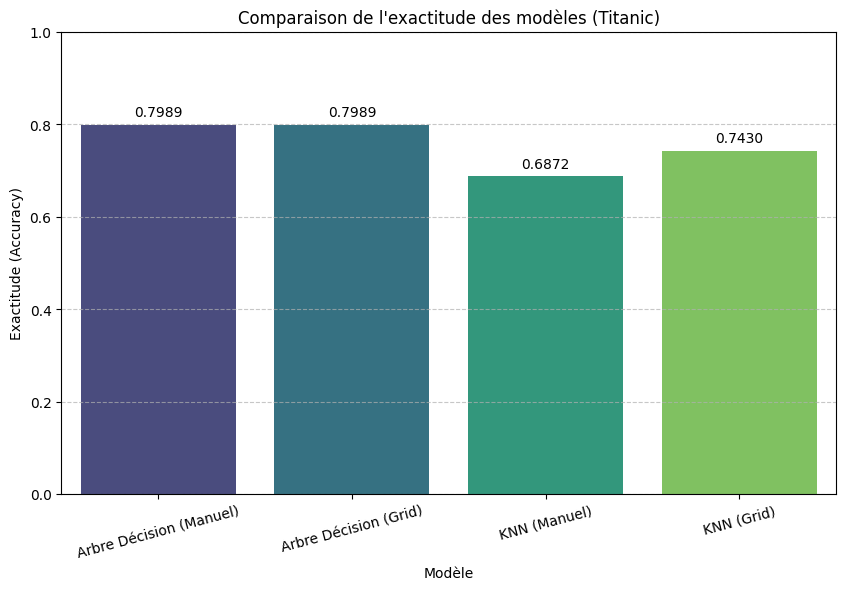

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vérification de l'existence du tableau récapitulatif
if 'df_titanic_summary' in globals():
    plt.figure(figsize=(10, 6)) # Définit la taille de la figure

    # Création du graphique à barres
    ax = sns.barplot(x='Modèle', y='Exactitude', data=df_titanic_summary, palette='viridis')

    # Ajout des étiquettes de score sur les barres
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

    plt.title('Comparaison de l\'exactitude des modèles (Titanic)') # Titre du graphique
    plt.ylim(0, 1.0) # Limite l'axe Y de 0 à 100%
    plt.ylabel('Exactitude (Accuracy)') # Nom de l'axe Y
    plt.xticks(rotation=15) # Rotation des noms des modèles pour la lisibilité
    plt.grid(axis='y', linestyle='--', alpha=0.7) # Ajout d'une grille horizontale
    plt.show() # Affichage
else:
    print("Le tableau récapitulatif 'df_titanic_summary' est introuvable.")

# Exercice XP Ninja - Réseaux Neuronaux Convolutifs (CNN)

In [17]:
import tensorflow as tf # Importation de TensorFlow
from tensorflow.keras import layers, models # Importation des composants Keras
from sklearn.preprocessing import LabelEncoder, MinMaxScaler # Pour le prétraitement

# Chargement d'un jeu de données exemple (MNIST car le lien original n'est pas fourni)
(x_train_n, y_train_n), (x_test_n, y_test_n) = tf.keras.datasets.mnist.load_data() # Charge les images de chiffres

# Mise à l'échelle des caractéristiques (Normalisation entre 0 et 1)
x_train_n = x_train_n.astype('float32') / 255.0 # Conversion et division par 255
x_test_n = x_test_n.astype('float32') / 255.0 # Idem pour le test

# Redimensionnement pour correspondre à l'entrée d'un CNN (Images 28x28 avec 1 canal)
x_train_n = x_train_n.reshape((-1, 28, 28, 1)) # Ajoute la dimension du canal
x_test_n = x_test_n.reshape((-1, 28, 28, 1)) # Idem pour le test

# Création du modèle séquentiel
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # Couche de convolution
    layers.MaxPooling2D((2, 2)), # Couche de pooling (réduction de dimension)
    layers.Flatten(), # Aplatissement des données pour les couches denses
    layers.Dense(64, activation='relu'), # Couche cachée dense
    layers.Dense(10, activation='softmax') # Couche de sortie pour 10 classes
]) # Modèle défini

# Compilation du modèle
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Configuration de l'entraînement

# Entraînement du modèle
cnn_model.fit(x_train_n, y_train_n, epochs=3, batch_size=64, validation_split=0.1) # Entraînement rapide

# Évaluation finale
loss, accuracy = cnn_model.evaluate(x_test_n, y_test_n) # Calcul de la perte et précision
print(f"Précision du CNN : {accuracy:.4f}") # Affiche le résultat final

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9387 - loss: 0.2152 - val_accuracy: 0.9795 - val_loss: 0.0758
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9789 - loss: 0.0721 - val_accuracy: 0.9840 - val_loss: 0.0646
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9850 - loss: 0.0496 - val_accuracy: 0.9847 - val_loss: 0.0574
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9832 - loss: 0.0526
Précision du CNN : 0.9832
